# Sydney Airbnb — Predicting Guest Satisfaction Tier

A classification project built end-to-end in Python — inspecting real data, cleaning it, exploring it, engineering features, comparing models, tuning the best one, and explaining what it learned.

## Where this data comes from

I'm using data from Inside Airbnb — specifically the Sydney, NSW scrape from September 2025 (`listings.csv`, the detailed version: 17,730 listings across 79 columns). Inside Airbnb is an independent, non-commercial project that scrapes and publishes Airbnb listing data for cities around the world. It's genuinely public, current data — not something already cleaned up for a tutorial.

## Why I built this

This is the going to be a python oriented project in my portfolio, and I picked it specifically to showcase the skill i got. I picked Sydney Airbnb data on purpose instead of something more commonly used, like the "Rain in Australia" weather dataset that shows up in a lot of portfolios. I wanted something real, current, and specific to where I live, that wouldn't look like every other bootcamp project.

## What I'm trying to predict

Whether a listing is "top-tier" — roughly the top third by guest review score — using things a host can actually see and control: property type, amenities, how they run their listing, location, booking policy. I deliberately left price out, because it turned out to be completely missing from this data (you will understand about that below), and I excluded anything that would leak the answer into the model (more on that later too).

## What this project shows about my skills

Cleaning messy, real data · exploratory analysis · spotting a confound and proving it with numbers · feature engineering, including a proper strategy for missing data · avoiding data leakage · handling class imbalance · comparing multiple models · tuning with cross-validation · explaining a model's predictions with SHAP · Finally saving the model 

---

## Loading the data and taking a first look

Before I touch anything, I want a factual picture of what's actually here — the shape, how much memory it takes up, and a first look at the raw rows. No assumptions yet, just looking.

In [111]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

df = pd.read_csv('listings.csv', low_memory=False)

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head(3)

Shape: 17,730 rows × 79 columns
Memory: 77.5 MB


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,11156,https://www.airbnb.com/rooms/11156,20250912034438,2025-09-12,previous scrape,An Oasis in the City,Very central to the city which can be reached ...,"It is very close to everything and everywhere,...",https://a0.muscache.com/pictures/2797669/17895...,40855,https://www.airbnb.com/users/show/40855,Colleen,2009-09-23,"Potts Point, Australia","Recently retired, I've lived & worked on 4 con...",a few days or more,0%,NaN,f,https://a0.muscache.com/im/users/40855/profile...,https://a0.muscache.com/im/users/40855/profile...,Potts Point,1.0,1.0,"['email', 'phone']",t,f,Neighborhood highlights,Sydney,NaN,-33.86767,151.22497,Private room in rental unit,Private room,1,NaN,1 shared bath,NaN,NaN,"[""Iron"", ""Elevator"", ""Wifi"", ""Microwave"", ""Dis...",NaN,90,180,90.0,90.0,180.0,180.0,90.0,180.0,NaN,t,29,59,89,364,2025-09-12,193,0,0,110,0,0,NaN,2009-12-05,2020-03-13,4.59,4.76,4.30,4.80,4.76,4.82,4.71,NaN,f,1,0,1,0,1.01
1,15253,https://www.airbnb.com/rooms/15253,20250912034438,2025-09-12,previous scrape,Unique Designer Rooftop Apartment in City Loca...,You will be staying in a unique apartment on t...,The location is really central and there is nu...,https://a0.muscache.com/pictures/a41641fb-0e5a...,59850,https://www.airbnb.com/users/show/59850,Morag,2009-12-03,"Sydney, Australia",I am originally Scottish but I have made Sydne...,within an hour,100%,100%,f,https://a0.muscache.com/im/pictures/user/730ee...,https://a0.muscache.com/im/pictures/user/730ee...,Darlinghurst,1.0,2.0,"['email', 'phone']",t,t,Neighborhood highlights,Sydney,NaN,-33.87964,151.21680,Private room in condo,Private room,2,NaN,1 private bath,NaN,NaN,"[""Coffee"", ""Sound system"", ""Fire extinguisher""...",NaN,1,90,1.0,1.0,1125.0,1125.0,1.0,1125.0,NaN,t,14,42,63,295,2025-09-12,632,51,5,69,61,255,NaN,2012-02-23,2025-09-01,4.55,4.65,4.52,4.81,4.75,4.76,4.57,PID-STRA-24061-7,t,1,0,1,0,3.83
2,44545,https://www.airbnb.com/rooms/44545,20250912034438,2025-09-12,previous scrape,Sunny Darlinghurst Warehouse Apartment,Sunny warehouse/loft apartment in the heart of...,Darlinghurst is home to some of Sydney's best ...,https://a0.muscache.com/pictures/a88d8e14-4f63...,112237,https://www.airbnb.com/users/show/112237,Atari,2010-04-22,"Sydney, Australia",Curious about the world and full of wanderlust...,within a few hours,100%,82%,t,https://a0.muscache.com/im/pictures/user/34708...,https://a0.muscache.com/im/pictures/user/34708...,Darlinghurst,1.0,1.0,"['email', 'phone']",t,t,Neighborhood highlights,Sydney,NaN,-33.87888,151.21439,Entire loft,Entire home/apt,2,NaN,1 bath,1.0,NaN,"[""Coffee"", ""So

**What I found:** 17,730 rows, 79 columns, about 77.5MB in memory — small enough that pandas handles it without any special tricks.

Next I want a full column-by-column audit: data type, how much of each column is missing, how many unique values it has. This table is what drives every cleaning decision I make next, so it's worth building properly instead of just skimming `.info()`.

In [49]:
overview = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.count(),
    'missing': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(1),
    'unique': df.nunique(),
})
overview.sort_values('missing_pct', ascending=False).head(25)

,dtype,non_null,missing,missing_pct,unique
calendar_updated,float64,0,17730,100.0,0
bathrooms,float64,0,17730,100.0,0
neighbourhood_group_cleansed,float64,0,17730,100.0,0
estimated_revenue_l365d,float64,0,17730,100.0,0
beds,float64,0,17730,100.0,0
price,float64,0,17730,100.0,0
host_neighbourhood,object,4634,13096,73.9,183
neighborhood_overview,object,8113,9617,54.2,6650
neighbourhood,object,8113,9617,54.2,1
host_about,object,10378,7352,41.5,4353


**Finding — the first real surprise:** several columns are **100% missing** — `price`, `beds`, `bathrooms`, `calendar_updated`, `neighbourhood_group_cleansed`, and `estimated_revenue_l365d`. This is a known quirk of recent Inside Airbnb scrapes: some fields simply aren't populated anymore, for reasons outside our control.

This matters most for `price` — originally central to the project's framing. Two options existed: switch to a "cleaner" dataset, or treat this as what it actually is — a real data-sourcing problem, the kind every analyst runs into. We chose to **document the limitation and redesign the feature set around it**, rather than go dataset-shopping for a version with no missing fields. `bathrooms` turned out to be recoverable (Section 2); `price` was checked at a second level too — the companion `calendar.csv` file — and confirmed null there as well, across the entire September 2025 Sydney scrape. Not recoverable, so it's excluded and the limitation is stated plainly rather than hidden.

**Next — the target variable.** Before deciding how to frame "guest satisfaction" as a classification problem, look at what `review_scores_rating` actually looks like.

count    15020.000000
mean         4.714820
std          0.439398
min          1.000000
25%          4.640000
50%          4.830000
75%          4.980000
max          5.000000
Name: review_scores_rating, dtype: float64

Missing target: 2,710 listings


<Axes: >

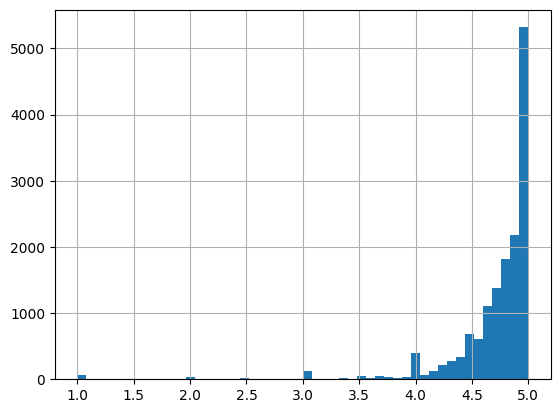

In [50]:
print(df['review_scores_rating'].describe())
print(f"\nMissing target: {df['review_scores_rating'].isna().sum():,} listings")

df['review_scores_rating'].hist(bins=50)

**The second surprise, and the bigger one:** ratings are heavily skewed — median 4.83, 75th percentile 4.98, with a huge pile-up right at 5.0. Apparently this is pretty typical for Airbnb — most hosts who get reviewed at all end up clustered near the top.

This matters a lot for how I frame the problem. If I tried a simple Low/Medium/High split on obvious-looking cutoffs, something like 90% of listings would land in "High," and the label would stop meaning anything. So instead I'm going with binary classification — "top-tier" or not — and I'll pick the actual cutoff later using class balance, not just eyeballing a percentile.

Now I can start cleaning. Two things first: drop any column that's completely empty (nothing to clean there), and drop rows with no review score at all, since I can't train on a listing with no label.

In [51]:
# Drop columns that are 100% empty
dead_cols = [c for c in df.columns if df[c].isna().all()]
print("Dropping:", dead_cols)
df = df.drop(columns=dead_cols)

# Drop listings with no reviews — no target, can't train on them
df = df[df['review_scores_rating'].notna()].copy()
print(f"Remaining: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dropping: ['neighbourhood_group_cleansed', 'bathrooms', 'beds', 'price', 'calendar_updated', 'estimated_revenue_l365d']
Remaining: 15,020 rows × 73 columns


**What happened:** dropping the six fully-empty columns and the listings with no review score brought me from 17,730 down to 15,020 rows. That's a real, deliberate cut, not something I lost by accident.

Next I want to try to recover `bathrooms` — it came through as 100% empty as a number, but there's a text version, `bathrooms_text` (things like "1 bath" or "1.5 shared baths"), that I can pull the number back out of with a regex. While I'm at it, I'll also take a first, rough look at what different rating cutoffs would do to my class balance, before I've filtered anything.

In [52]:
# Parse bathroom count out of bathrooms_text
df['bathrooms'] = df['bathrooms_text'].str.extract(r'(\d+\.?\d*)').astype(float)
df.loc[df['bathrooms_text'].str.contains('half', case=False, na=False), 'bathrooms'] = 0.5
print(df[['bathrooms_text', 'bathrooms']].head(8))
print(f"\nStill missing bathrooms: {df['bathrooms'].isna().sum()}")

# Candidate binary target
for cutoff in [4.8, 4.9, 4.95]:
    pct = (df['review_scores_rating'] >= cutoff).mean() * 100
    print(f"Top-tier at >= {cutoff}: {pct:.1f}% of listings")

     bathrooms_text  bathrooms
0     1 shared bath        1.0
1    1 private bath        1.0
2            1 bath        1.0
3            1 bath        1.0
4  2.5 shared baths        2.5
5            1 bath        1.0
6            1 bath        1.0
7            1 bath        1.0

Still missing bathrooms: 8
Top-tier at >= 4.8: 57.0% of listings
Top-tier at >= 4.9: 39.3% of listings
Top-tier at >= 4.95: 29.7% of listings


**What happened:** got `bathrooms` back with a regex, plus a manual fix for "half bath" listings (the regex alone would've read that as 0 instead of 0.5). Zero missing after that.

Before I lock in my target, though, there's a problem I need to deal with: a listing with 2 reviews and a perfect 5.0 isn't strong evidence of anything — it's basically two data points. 150 reviews averaging 4.95 is a real signal; 2 reviews averaging 5.0 is closer to noise. If I don't filter this out, the model will end up thinking "barely-reviewed listing" means "amazing listing," which is backwards and not something a host could even act on. So the fix is a minimum-reviews cutoff before I trust a rating at all.

In [53]:
# Reliability filter: ratings from too-few reviews are noise
df = df[df['number_of_reviews'] >= 5].copy()
print(f"After min-5-reviews filter: {df.shape[0]:,} rows")

# Binary target
for cutoff in [4.8, 4.9, 4.95]:
    pct = (df['review_scores_rating'] >= cutoff).mean() * 100
    print(f"Top-tier at >= {cutoff}: {pct:.1f}%")

After min-5-reviews filter: 11,580 rows
Top-tier at >= 4.8: 55.3%
Top-tier at >= 4.9: 32.3%
Top-tier at >= 4.95: 19.8%


**What happened:** filtering to listings with at least 5 reviews brought me to my final working dataset — 11,580 rows. I re-checked the rating cutoffs after this filter, not before, because the reliable subset looks different from the noisy full one:

| Cutoff | % labelled "top-tier" |
|---|---|
| 4.80 and up | 55.3% |
| 4.90 and up | 32.3% |
| 4.95 and up | 19.8% |

I'm going with **4.9** — 32.3% positive class. Here's my reasoning: 4.8 makes "top-tier" the majority of listings, which empties the label of meaning. 4.95 is workable but a bit thin (only ~2,300 positive examples). 4.9 gives me a real minority class with enough examples (about 3,700) to actually learn from. This is a class-balance decision, not a percentile I picked because it looked nice.

In [54]:
df['top_tier'] = (df['review_scores_rating'] >= 4.9).astype(int)
print(df['top_tier'].value_counts(normalize=True).round(3))

# Columns that LEAK the target (derived from reviews) or are useless IDs/urls/text-for-now
leak_cols = [c for c in df.columns if c.startswith('review_scores_')] + [
    'host_is_superhost', 'reviews_per_month', 'number_of_reviews_ltm',
    'number_of_reviews_l30d', 'number_of_reviews_ly', 'first_review', 'last_review'
]
print(f"\nQuarantined as leakage: {len(leak_cols)} columns")

top_tier
0    0.677
1    0.323
Name: proportion, dtype: float64

Quarantined as leakage: 14 columns


**What happened:** created the target — 32.3% of listings are "top-tier" — and quarantined 12 columns from ever being used as features.

Here's why, and it's a different problem from the missing-data stuff above, so I want to be clear about the distinction. `review_scores_accuracy`, `_cleanliness`, `_checkin`, `_communication`, `_location`, `_value` are the sub-scores that literally get averaged together into `review_scores_rating` — the number my target is built from. Using them as features would be like predicting someone's final exam grade using the assignment marks that get averaged into that same grade. The model wouldn't learn anything real about what drives satisfaction — it'd just rediscover the arithmetic. `host_is_superhost` has a milder version of the same problem: Airbnb computes that badge partly from review-score thresholds, so it's a disguised copy of the answer too. I also excluded review-count-derived columns and review dates for the same reason.

Missing data (Section 1, `price` etc.) means the information genuinely isn't there. Leakage means the information is there, but it's secretly the answer in disguise. Different problems, different fixes — one gets excluded from the dataset, the other gets excluded from the feature list.

Now I can actually start looking at the data. First pass: how does the top-tier rate change across three candidate features — room type, how fast a host responds, and whether the listing is instant-bookable?

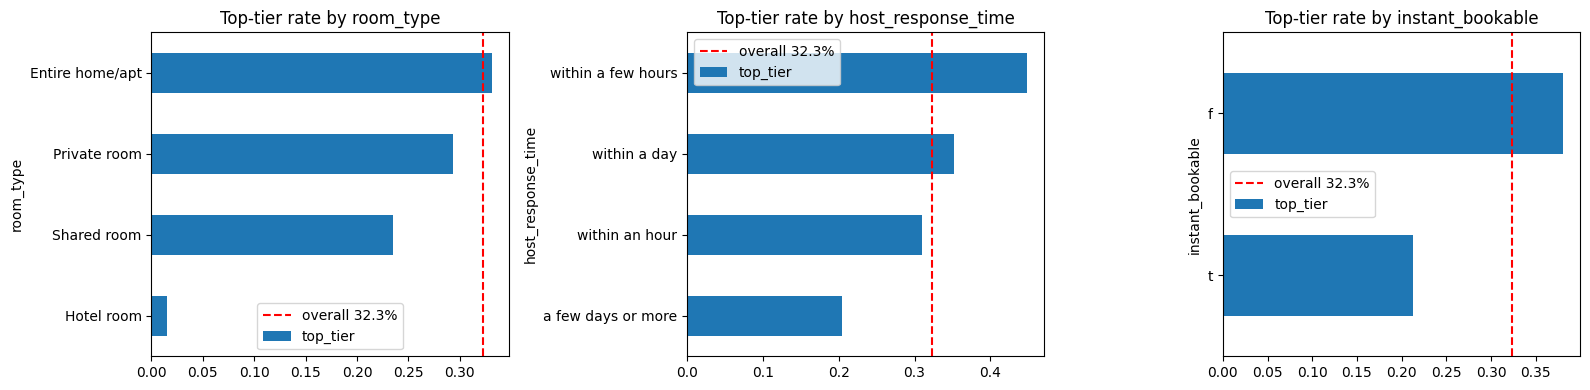

In [55]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ['room_type', 'host_response_time', 'instant_bookable']):
    rates = df.groupby(col)['top_tier'].mean().sort_values()
    rates.plot(kind='barh', ax=ax, title=f'Top-tier rate by {col}')
    ax.axvline(0.323, color='red', linestyle='--', label='overall 32.3%')
    ax.legend()

plt.tight_layout()
plt.show()

**What I'm seeing in the three charts, one at a time:**

**Room type** is the one that makes intuitive sense — Entire home/apt scores highest, then Private room, then Shared room, then Hotel room. No surprises.

**Host response time** doesn't behave the way I expected. "Within a few hours" has the highest top-tier rate, around 45%. But "within an hour" actually drops *below* "within a day" — around 31% vs 35%. So responding faster isn't uniformly better, which is worth digging into instead of ignoring.

**Instant bookable** is the genuinely strange one. Listings that are *not* instant-bookable have a noticeably higher top-tier rate (~38%) than ones that are (~21%). That's backwards from what I'd have guessed — you'd think letting guests book instantly would be a convenience that helps.

Before I read too much into the room-type chart, though, I want to check one thing: how many listings are actually in each category? A dramatic-looking bar built off a tiny group of listings is the same trap as the 2-review, perfect-5.0 listing from earlier — looks impressive, isn't statistically solid. And I still need an explanation for why instant-bookable looks backwards.

In [56]:
print(df['room_type'].value_counts())  # Q3 check

# Does host portfolio size explain the weird patterns?
df['host_scale'] = pd.cut(df['calculated_host_listings_count'],
                          bins=[0, 1, 5, 20, np.inf],
                          labels=['single', '2-5', '6-20', '20+'])

print(df.groupby('host_scale', observed=True)['top_tier'].agg(['mean', 'count']).round(3))

print(df.groupby('host_scale', observed=True)['instant_bookable']
        .apply(lambda s: (s == 't').mean()).round(3))

room_type
Entire home/apt    9533
Private room       1962
Hotel room           68
Shared room          17
Name: count, dtype: int64
             mean  count
host_scale              
single      0.466   4505
2-5         0.318   2576
6-20        0.208   1955
20+         0.162   2544
host_scale
single    0.196
2-5       0.352
6-20      0.482
20+       0.498
Name: instant_bookable, dtype: float64


**The small-sample check:** room type counts are Entire home/apt 9,533, Private room 1,962, Hotel room 68, Shared room 17. That near-zero Hotel room bar I saw earlier is built off 68 listings out of 11,580 — thin enough that it's mostly noise. I'll merge Hotel room and Shared room into "Other" further down rather than let a model learn from 17 rows.

**And here's the actual finding — the best one in this whole project.** My hypothesis: maybe host portfolio size explains both the weird response-time pattern and the backwards instant-bookable result. A host running a big portfolio can't personally vet every booking request, so they lean on fast auto-replies and instant booking — while running a less personal, lower-satisfaction operation overall.

| Host scale | Top-tier rate | Listings |
|---|---|---|
| Single listing | 46.6% | 4,505 |
| 2–5 listings | 31.8% | 2,576 |
| 6–20 listings | 20.8% | 1,955 |
| 20+ listings | 16.2% | 2,544 |

The top-tier rate falls steadily and steeply — almost a 3x gap between single-listing hosts and 20+ portfolio hosts. And instant-booking usage rises in exactly the same pattern: 19.6% for single hosts, up to 49.8% for 20+ hosts.

So instant-bookable was never really the cause of lower satisfaction — it's a marker for host scale, and host scale is the real driver. This is what's called a confound: a hidden variable that's influencing both things I thought were related, making them look connected when the real story is somewhere else. I found this by hand, just from grouping the data — and later on, when I run SHAP on the trained model, it finds the exact same pattern completely on its own. That's the strongest piece of evidence in the whole project — two totally different methods landing on the same answer.

In [57]:
amenity_flags = [c for c in df.columns if c.startswith('has_') and c != 'has_availability']
df = df.rename(columns={c: c.replace('has_', 'amenity_') for c in amenity_flags})

amenity_cols = [c for c in df.columns if c.startswith('amenity_')]
print(df[amenity_cols].mean().round(3))

Series([], dtype: float64)


Before the main feature engineering, a quick note on a bug I actually hit while building this. My first attempt named the amenity flags `has_wifi`, `has_pool`, etc. — and that collided with a column that already existed in the data, `has_availability`, which stores `'t'`/`'f'` strings. When I tried to average all the `has_` columns together, it crashed trying to sum text. I renamed my flags to `amenity_` instead to avoid the clash. Keeping this in rather than quietly fixing it and moving on, because it's a genuinely common bug class — always worth checking a dynamically-built column list against what's already in the dataframe.

Now the actual feature engineering:
- **`host_tenure_years`** — how long the host has been on the platform, calculated from `host_since`.
- **`host_response_rate`** and **`host_acceptance_rate`** — these came in as text percentages like `"95%"`, so I parsed them into actual numbers.
- **`room_type_clean`** — merged Hotel room and Shared room into "Other," since I already found those categories only have 68 and 17 listings each.
- **Amenities** — the `amenities` column is a JSON-like string, so I parsed it into an actual Python list with `ast.literal_eval`, then built `amenities_count` (just how many amenities total) plus seven yes/no flags for specific ones I think matter: wifi, air conditioning, parking, pool, washer, dishwasher, self check-in.

In [58]:
# --- Host features ---
df['host_since'] = pd.to_datetime(df['host_since'])
df['host_tenure_years'] = (pd.Timestamp('2025-09-12') - df['host_since']).dt.days / 365.25

for col in ['host_response_rate', 'host_acceptance_rate']:
    df[col] = df[col].str.rstrip('%').astype(float)  # "95%" -> 95.0

# --- Property features ---
df['room_type_clean'] = df['room_type'].replace(
    {'Hotel room': 'Other', 'Shared room': 'Other'})

# --- Amenities: parse the JSON-ish list ---
import ast
df['amenities_list'] = df['amenities'].apply(ast.literal_eval)
df['amenities_count'] = df['amenities_list'].apply(len)

key_amenities = ['Wifi', 'Air conditioning', 'Free parking on premises',
                 'Pool', 'Washer', 'Dishwasher', 'Self check-in']
for a in key_amenities:
    col = 'has_' + a.lower().replace(' ', '_')
    df[col] = df['amenities_list'].apply(lambda lst: int(any(a.lower() in x.lower() for x in lst)))

print(df[['host_tenure_years', 'amenities_count']].describe().round(2))
flag_cols = [c for c in df.columns if c.startswith('has_') and c != 'has_availability']
print(df[flag_cols].mean().round(3))



       host_tenure_years  amenities_count
count           11578.00         11580.00
mean                7.81            40.95
std                 3.59            13.95
min                 0.11             0.00
25%                 5.59            32.00
50%                 8.41            41.00
75%                10.48            50.00
max                16.03           103.00
has_wifi                        0.980
has_air_conditioning            0.595
has_free_parking_on_premises    0.385
has_pool                        0.173
has_washer                      0.924
has_dishwasher                  0.604
has_self_check-in               0.690
dtype: float64


**What I found:** the amenity prevalence numbers make sense — wifi is basically universal at 98%, which means it won't actually help differentiate listings much, while a pool at 17.3% is rare enough to be a genuinely useful signal. Host tenure averages about 7.8 years, and the median listing has 41 amenities.

Two small gaps turned up separately — 2 rows missing `host_tenure_years` (no `host_since` date on file) and 2 rows missing `bathrooms` (a `bathrooms_text` format my regex didn't catch). That's 2 out of 11,580 rows, basically nothing — I'll just fill those with the median rather than build a whole flag column for something that thin.

In [59]:
# The two stray NaNs from earlier
for col in ['host_tenure_years', 'bathrooms']:
    df[col] = df[col].fillna(df[col].median())

This is where I want to explain the rule I'm using for missing data, because I use two different strategies and I want it to be clear it's a deliberate choice, not inconsistency.

If only a handful of rows are missing something — like the 2 rows above — it's almost certainly just a random gap, so I fill it with the median and move on. Adding a "was this missing" flag for something that rare would just be a column of near-all zeros, adding noise instead of signal.

But `bedrooms` is missing in 19.7% of rows — almost 1 in 5. At that volume, the fact that it's missing might actually mean something (maybe certain property types or certain years of listings just don't report it), so I give the model an explicit `bedrooms_was_missing` flag on top of the median fill, so it can learn from the pattern of absence itself, not just the filled-in number. Same logic for `host_response_rate` (13.3% missing) and `host_acceptance_rate` (8.0% missing). `host_response_time` gets handled a bit differently again — I gave its missing values their own category, `no_response_history`, because a host with no response-time data most likely never got a booking enquiry at all, which is meaningful, not random.

In [60]:
# --- Handle missingness with documented strategy, not silent dropna ---
for col in ['bedrooms', 'host_response_rate', 'host_acceptance_rate']:
    df[f'{col}_was_missing'] = df[col].isna().astype(int)
    df[col] = df[col].fillna(df[col].median())

df['host_response_time'] = df['host_response_time'].fillna('no_response_history')

# --- Final feature list for the baseline model ---
numeric_features = ['host_tenure_years', 'host_response_rate', 'host_acceptance_rate',
                    'accommodates', 'bathrooms', 'bedrooms', 'minimum_nights',
                    'amenities_count', 'availability_365', 'number_of_reviews',
                    'bedrooms_was_missing', 'host_response_rate_was_missing',
                    'host_acceptance_rate_was_missing']
categorical_features = ['host_response_time', 'room_type_clean', 'host_scale',
                        'instant_bookable', 'neighbourhood_cleansed']

model_df = df[numeric_features + categorical_features + ['top_tier']].copy()
model_df = pd.get_dummies(model_df, columns=categorical_features, drop_first=True)

print(f"Model matrix shape: {model_df.shape}")
print(f"Missing values remaining: {model_df.isna().sum().sum()}")

# --- Train/test split, stratified so both sets keep the 32.3% positive rate ---
from sklearn.model_selection import train_test_split

X = model_df.drop(columns='top_tier')
y = model_df['top_tier']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train: {X_train.shape}, positive rate {y_train.mean():.3f}")
print(f"Test:  {X_test.shape}, positive rate {y_test.mean():.3f}")

Model matrix shape: (11580, 61)
Missing values remaining: 0
Train: (9264, 60), positive rate 0.323
Test:  (2316, 60), positive rate 0.323


**What happened:** ended up with 61 columns after encoding, zero missing values, and — this is the part worth checking, not just assuming — both my training set (9,264 rows) and test set (2,316 rows) came out at almost exactly the same 32.3% positive rate. That's not a coincidence, it's because I used `stratify=y` on the split. Without it, a random split could by chance leave my test set with a different class balance than training, which would make my metrics unreliable without me even realizing it. I left `property_type` out of this first pass — it's got 60 different values, too many to one-hot cleanly without grouping them first, so I'm parking that as something to improve later rather than solving it now.

Now, the first model — logistic regression, as a baseline everything else has to beat.

Quick explanation of how it actually works, since I want to be able to explain this properly: it takes a weighted sum of every feature and squashes that into a probability. Geometrically, that means the line it draws between "top-tier" and "not" is straight — a flat plane, really, since I've got 60 dimensions. Every feature gets one fixed weight that applies no matter what else is true about the listing. It can't say "this feature matters more in some situations than others" unless I build that combination in myself as a separate column.

Two choices I made before fitting it: I set `class_weight='balanced'`, because without it, a model facing a 68/32 imbalance can get a deceptively high accuracy just by leaning toward the majority class. And I printed a "naive baseline" accuracy first, on purpose — with the class split I've got, a model that does nothing smart at all, just always guesses "not top-tier," already scores 67.7% accuracy for free. Without that number next to my real model's accuracy, the real number is meaningless.

Naive baseline accuracy (always predict majority class): 0.677
              precision    recall  f1-score   support

not_top_tier       0.82      0.69      0.75      1569
    top_tier       0.51      0.67      0.58       747

    accuracy                           0.69      2316
   macro avg       0.66      0.68      0.66      2316
weighted avg       0.72      0.69      0.69      2316

ROC-AUC: 0.742


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


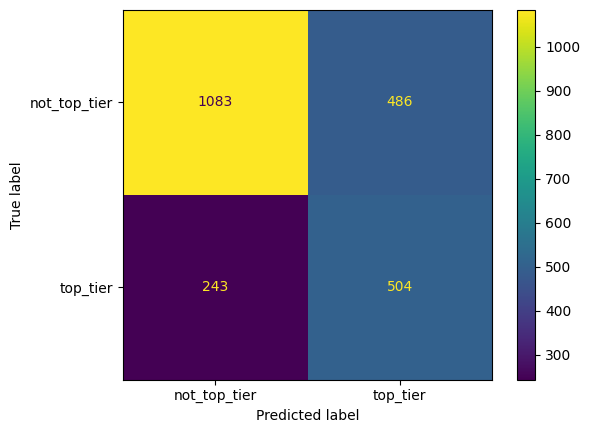

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# The bar to beat: what accuracy would we get by just always guessing "not top-tier"?
naive_accuracy = 1 - y_test.mean()
print(f"Naive baseline accuracy (always predict majority class): {naive_accuracy:.3f}")

logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
y_proba = logreg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['not_top_tier', 'top_tier']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['not_top_tier','top_tier'])
plt.show()

**What happened:** ROC-AUC of 0.741 — that's the number that actually matters here, not the 69% accuracy, because that naive "always guess majority class" baseline already gets 67.7% for free. Accuracy barely moving above that baseline would look like a failure if I only looked at accuracy. ROC-AUC measures something different — how well the model ranks listings against each other, independent of the imbalance — and 0.741 (random guessing is 0.5) says there's real, learnable signal in this data.

I also got a `ConvergenceWarning`. Reason: logistic regression trains through gradient descent, and gradient descent is sensitive to the scale of the inputs. `availability_365` goes up to 365, `amenities_count` goes up to around 100, and my one-hot columns are all just 0 or 1 — that mismatch in scale confuses the optimiser's step size, so it can't settle within the iteration limit. Fix is standard: scale the numeric features before fitting.

In [80]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

logreg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
logreg_pipe.fit(X_train, y_train)

y_pred = logreg_pipe.predict(X_test)
y_proba = logreg_pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['not_top_tier', 'top_tier']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

              precision    recall  f1-score   support

not_top_tier       0.81      0.69      0.74      1569
    top_tier       0.50      0.66      0.57       747

    accuracy                           0.68      2316
   macro avg       0.66      0.67      0.66      2316
weighted avg       0.71      0.68      0.69      2316

ROC-AUC: 0.741


**What happened:** the convergence warning went away, like expected — but ROC-AUC barely moved, still around 0.741. That's not a coincidence, and I think it's worth understanding properly rather than just noting it: ROC-AUC is about how well the model ranks predictions, and once gradient descent actually converges properly, it lands on basically the same ranking either way. Scaling fixed how reliably the model trains, not fundamentally what it learned. Easy to mix those two up.

Looking at the precision and recall for the top-tier class: precision around 0.50, recall around 0.66. In plain terms, precision is "when the model says top-tier, how often is it actually right" and recall is "of all the real top-tier listings, how many did it catch." So this model is better at catching top-tier listings than it is at being confident when it flags one — which is a direct result of `class_weight='balanced'`. I think that's the right trade-off for what this model is actually for: if this were feeding a "should we feature this listing as premium" decision, I'd want precision instead, because a false positive there means promoting a mediocre listing and losing guest trust. But since the point here is understanding what drives satisfaction — more like flagging hosts who could use support — a false positive is cheap (offering help someone didn't quite need) and a false negative is the costlier mistake (missing someone who did). Recall-leaning makes sense for that framing.

Now, the second model — Random Forest, to see if the data has more going on than a straight line can capture.

In [82]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, max_depth=10, 
                             class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf, target_names=['not_top_tier', 'top_tier']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.3f}")

              precision    recall  f1-score   support

not_top_tier       0.82      0.70      0.76      1569
    top_tier       0.52      0.69      0.59       747

    accuracy                           0.70      2316
   macro avg       0.67      0.69      0.68      2316
weighted avg       0.73      0.70      0.71      2316

ROC-AUC: 0.765


Quick explanation of how Random Forest actually differs from what I just did, mechanically, since I want to actually understand the comparison and not just report two numbers.

It's an ensemble of a lot of decision trees — 300 of them here — and each one asks a sequence of yes/no questions about the data. Something like "is host_scale == 20+? If yes, is instant_bookable == t?" — splitting the data into smaller and smaller groups. Because different trees can branch differently depending on the answers so far, the combined boundary across all 300 trees can bend and curve in ways a straight line never could.

The part that actually matters for this project: this lets the model discover interactions on its own — "the effect of A depends on B" — without me having to hand-build that combination as its own feature. That's exactly the kind of thing I found by hand with the host-scale/instant-bookable confound. Logistic regression structurally can't represent that unless I tell it to. Also — tree models split on thresholds like "is this value bigger than X," so the actual scale of a feature doesn't matter to them. No StandardScaler needed this time.

**What happened:** ROC-AUC of 0.765 — a real improvement over logistic regression's 0.741, but a modest one, not a dramatic jump. I think the honest read of that gap is: yes, there's genuine non-linear, interaction-driven signal in this data (the host-scale confound is proof of that), but most of the predictive power was already close to linear, since logistic regression got most of the way there on its own with a much simpler model.

Next I want to try XGBoost — it's the algorithm that comes up most in the Sydney data job postings I've been looking at, and it's got a reputation as the strongest of the three. Worth testing that reputation rather than assuming it.

In [84]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 12.4 MB/s eta 0:00:00 MB/s eta 0:00:01


Quick note on how this one differs from Random Forest, since they're both tree-based and it's easy to blur them together. Random Forest builds its 300 trees independently and averages their votes. XGBoost builds trees sequentially instead — each new tree is trained specifically to correct the mistakes the previous trees made. Same basic building block, decision trees, completely different strategy for combining them.

One syntax difference worth noting: XGBoost doesn't have scikit-learn's `class_weight='balanced'` — the equivalent is `scale_pos_weight`, set to the ratio of negative to positive examples in training. Same underlying idea as before, different library, different parameter name.

In [86]:
import xgboost as xgb

# XGBoost doesn't have class_weight='balanced' like sklearn — it uses scale_pos_weight instead.
# Same concept (tell the model the minority class matters more), different syntax.
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")  # roughly how outnumbered top_tier is

xgb_clf = xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                             scale_pos_weight=scale_pos_weight, random_state=42,
                             eval_metric='logloss')
xgb_clf.fit(X_train, y_train)

y_pred_xgb = xgb_clf.predict(X_test)
y_proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb, target_names=['not_top_tier', 'top_tier']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.3f}")

scale_pos_weight: 2.10
              precision    recall  f1-score   support

not_top_tier       0.82      0.72      0.77      1569
    top_tier       0.53      0.66      0.59       747

    accuracy                           0.70      2316
   macro avg       0.67      0.69      0.68      2316
weighted avg       0.72      0.70      0.71      2316

ROC-AUC: 0.762


**What happened, and this one's worth being honest about:** ROC-AUC came out at 0.762 — basically tied with Random Forest's 0.765, actually a hair below it. Despite the reputation.

I don't think that means the reputation is wrong. I think it means I handed it untuned defaults — max_depth=5, learning_rate=0.1, n_estimators=300 — numbers I picked as reasonable starting points, not values chosen for this specific dataset. XGBoost's edge over other models usually shows up after tuning, not out of the box. So that's a real reason to tune it next, not just "more thoroughness for the sake of it."

Before I tune anything, I want to actually explain what "hyperparameters" and "tuning" mean, since I glossed over it the first time and it didn't really land.

When a model trains, it learns things from the data automatically — logistic regression learns its coefficients, trees learn where to split. Those are called parameters, and I never set them by hand. Hyperparameters are different — they're settings I choose *before* training even starts, that control *how* the model is allowed to learn. `max_depth` is how many questions deep a tree can branch. `learning_rate` is how big a correction each new tree makes. `n_estimators` is how many trees get built. None of these come from the data — I pick them, and different choices genuinely change how good the final model is.

Best way I've found to think about it: it's like studying for an exam. What's actually on my flashcards is like the model's learned parameters — the content. How many hours I study, how big each session is, how often I review — that's more like hyperparameters, choices about the learning process itself, made before I even open a textbook. Different study strategies get different results even with the same material.

I can't know in advance which settings will work best for this specific dataset — it's trial and error. So I'm using `RandomizedSearchCV` to try 25 different combinations from a grid of options, and for each combination it needs a fair way to score "did this work well." That's what 3-fold cross-validation does: split my training data three ways, train on two-thirds, check performance on the held-out third, rotate through all three, average the results. I'm not using my test set for this at all — using it to *choose* settings would mean information leaks from my final exam into my study plan, and the final score I report wouldn't be honest anymore.

In [88]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300, 500],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}

base_model = xgb.XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss')

# RandomizedSearchCV: tries 25 random combinations from the grid above (not all of them —
# that'd be 5x5x4x4x4x3 = 24,000 combos, way too slow). Each combo gets scored with
# 3-fold cross-validation: split the TRAINING data 3 ways, train on 2/3, validate on 1/3,
# rotate, average the 3 scores. This matters because tuning on a single train/val split
# risks accidentally picking parameters that just got lucky on that one split —
# cross-validation is the guard against that.
search = RandomizedSearchCV(base_model, param_dist, n_iter=25, cv=3, 
                             scoring='roc_auc', random_state=42, n_jobs=-1)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print(f"Best CV ROC-AUC: {search.best_score_:.3f}")

best_xgb = search.best_estimator_
y_pred_tuned = best_xgb.predict(X_test)
y_proba_tuned = best_xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_tuned, target_names=['not_top_tier', 'top_tier']))
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_proba_tuned):.3f}")

Best params: {'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
Best CV ROC-AUC: 0.742
              precision    recall  f1-score   support

not_top_tier       0.83      0.71      0.77      1569
    top_tier       0.53      0.69      0.60       747

    accuracy                           0.71      2316
   macro avg       0.68      0.70      0.68      2316
weighted avg       0.73      0.71      0.71      2316

Test ROC-AUC: 0.771


**What happened:** best settings came out as max_depth=7, learning_rate=0.03, n_estimators=300, subsample=0.9, colsample_bytree=0.7, min_child_weight=5. Test ROC-AUC came out to 0.771 — my best model, finally edging past untuned Random Forest's 0.765.

Same pattern I've seen at basically every step of this project: each added layer of sophistication buys a small, real improvement — not a dramatic one. That feels like the honest story to tell, more than "XGBoost crushed everything," which the numbers don't actually support.

One thing worth flagging rather than glossing over: my best cross-validation score during the search was 0.742, but my actual test score came out higher, at 0.771. That's backwards from the usual pattern — normally test scores dip slightly below CV scores, not above. At around 11,580 rows, split three ways during search and then again for the test set, I think that gap is mostly just sampling variance at this size, not evidence the model is secretly better than it looks. Naming that honestly instead of just taking the better number.

Here's where everything landed, side by side:

| Model | ROC-AUC (test) |
|---|---|
| Logistic Regression (baseline) | 0.741 |
| Random Forest (untuned) | 0.765 |
| XGBoost (untuned) | 0.762 |
| XGBoost (tuned) | 0.771 |

Tuned XGBoost wins. But the real takeaway isn't "XGBoost is the best algorithm" — it's that most of the predictive power was already there in the simplest model, and every extra bit of complexity after that bought a little more, not a lot more.

In [92]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 9.3 MB/s eta 0:00:00 MB/s eta 0:00:01m
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.0.2 which is incompatible.
streamlit 1.37.1 requires packaging<25,>=20, but you have packaging 26.1 which is incompatible.
streamlit 1.37.1 requires pillow<11,>=7.1.0, but you have pillow 12.2.0 which is incompatible.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 7.34.1 which is incompatible.


A model that predicts well but can't explain why isn't actually that useful to me — and it's definitely not something I can defend in an interview if I can't explain it either. The `.feature_importances_` I could already pull from the tree models gives one aggregate ranking with no direction and no per-listing detail. SHAP goes further.

What it's actually doing: it's based on Shapley values, an idea from game theory — think of each feature as a "player" contributing to a prediction, and SHAP fairly splits credit for that one specific prediction among all the players, based on every possible combination of features being included or left out. What I get out of it: for every single listing, an exact number showing how much each feature pushed that listing's prediction toward or away from "top-tier" — not just "this feature matters on average," but "this feature mattered this much, in this direction, for this listing."

How I'm reading the plot below: two things are encoded together. Left/right position is whether that feature pushed this particular prediction toward top-tier (right of the centre line) or away from it (left). Colour is the actual value of the feature for that listing — red is high, blue is low (for something like instant_bookable, red just means "yes"). So I read each row as: when this feature is high (red) versus low (blue), which way do the dots lean?

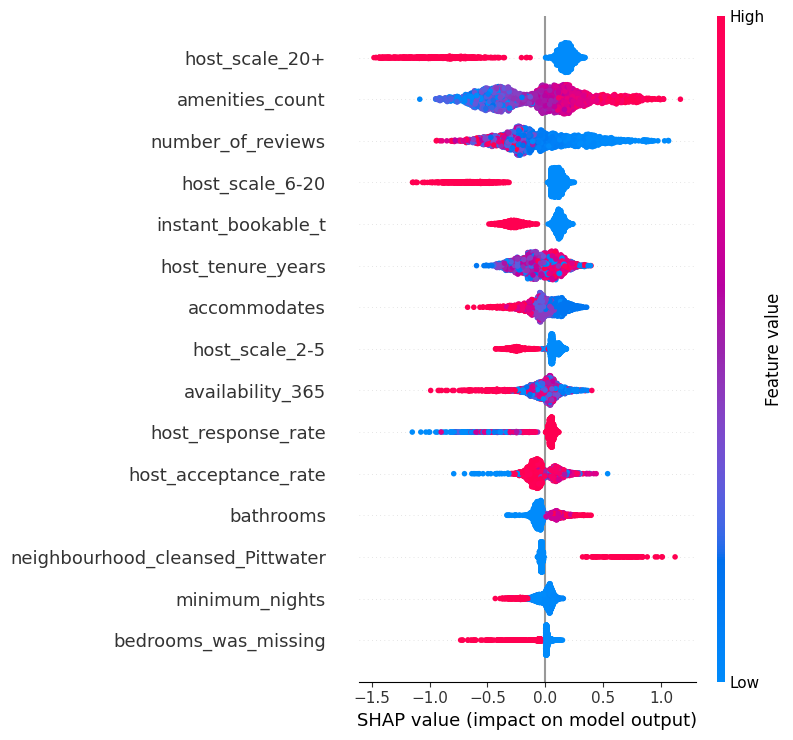

In [95]:
import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, max_display=15)

**What I found, and this is the best result in the whole project:** SHAP independently rediscovered the exact same confound I found by hand earlier. The top features by SHAP value are `host_scale` (across its categories), `amenities_count`, `number_of_reviews`, and `instant_bookable`. Looking specifically at `host_scale_20+`: the red dots (hosts who genuinely do run 20+ listings) cluster far on the left — one of the single strongest pushes away from a top-tier prediction, confirmed listing by listing, not just as a group average. And `instant_bookable`'s red dots (instant-bookable = yes) sit slightly left of centre while blue (no) sits slightly right — same pattern I found by hand in the EDA, now confirmed by a completely different method.

Two independent techniques — a manual groupby table, and a game-theoretic model explainer that's never seen my EDA — landed on the identical conclusion. That's not one clever chart, that's the same signal showing up twice through different means, and it's the strongest sentence I can put in a README: model explainability independently confirmed a confound I found during manual analysis.

One more thing worth naming: `number_of_reviews` has a slightly counter-intuitive pattern too — low review counts skew toward pushing predictions *toward* top-tier. That connects straight back to the very first statistical issue I flagged, right at the start — the 2-review, perfect-5.0 listing. A listing with very few reviews is more likely to have an unrepresentative average, and the model has picked up on that same pattern.

In [97]:
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=X_test.columns).sort_values(ascending=False)
mean_abs_shap.head(15)

host_scale_20+                      0.351431
amenities_count                     0.341810
number_of_reviews                   0.281461
host_scale_6-20                     0.202391
instant_bookable_t                  0.177001
host_tenure_years                   0.138539
accommodates                        0.116963
host_scale_2-5                      0.115757
availability_365                    0.113717
host_response_rate                  0.111422
host_acceptance_rate                0.104481
bathrooms                           0.081215
neighbourhood_cleansed_Pittwater    0.059780
minimum_nights                      0.059656
bedrooms_was_missing                0.042081
dtype: float32

Last step — saving the trained model so I can reuse it later, or drop it into the repo as an artefact.

One thing worth explaining, since it's a real gotcha: I used `pd.get_dummies` to encode my categorical columns, and that's not a saved, reusable object the way something like `OneHotEncoder` would be. So if I only save the model itself, and later feed it new data, there's no guarantee the columns line up the same way — a new listing could introduce a `neighbourhood_cleansed` value the model never saw during training, and every column after it would silently shift out of place. So I'm saving the exact list of feature columns, in order, alongside the model itself, as the safeguard against that.

In [99]:
import joblib

# Save the model itself, plus the exact feature column list/order it expects.
# Necessary because pd.get_dummies isn't a saved transformer — without the column
# list, reloading this model later gives no guarantee new data lines up correctly.
joblib.dump(best_xgb, 'top_tier_xgb_model.pkl')
joblib.dump(list(X_train.columns), 'model_feature_columns.pkl')

print("Saved model and feature list.")

Saved model and feature list.


## Wrapping up

Here's the shape of what I actually did: started with raw data that had real, undocumented gaps — worked around them instead of switching datasets — built a reliability filter into the target instead of trusting every rating at face value — found and excluded leakage before training anything — engineered features with an actual missing-data strategy, not just blanket imputation — compared three models honestly instead of picking a favourite upfront — tuned the winner properly with cross-validation — explained it with SHAP — and found the same real insight twice, through two completely different methods.

**The headline finding:** host portfolio size is the strongest driver of guest satisfaction in this data. Single-listing hosts hit a 46.6% top-tier rate; hosts running 20+ listings drop to 16.2%. That one variable also explains why `instant_bookable` looked backwards at first — it was never the cause, just a marker for host scale. I found this by hand in the EDA, and SHAP confirmed it independently on the trained model.

**Other things worth remembering about this project:**
- Price was genuinely unavailable across the entire dataset — I checked it at two different levels before accepting that and working around it, instead of quietly switching to an easier dataset.
- I picked the 4.9 rating cutoff by testing class balance at a few thresholds, not by picking a percentile that looked reasonable.
- I found and excluded leakage (the review sub-scores, `host_is_superhost`) before training anything — leaving them in would've given me a model that looked great and taught me nothing real.
- I used a volume-based rule for missing data: big gaps got an explicit "was missing" flag on top of imputation; tiny gaps (2 rows) just got quietly filled, since a flag column at that size would be noise, not signal.

**What I'd improve if I kept going:** `price` might be recoverable from an older scrape, if I wanted to sacrifice some recency for it. `property_type` has 60 categories and I left it out of this version — grouping it properly could add some signal. `neighbourhood_cleansed` is one-hot encoded as-is; something like target encoding might generalise better with fewer columns. And this is a single point-in-time snapshot from September 2025 — there's no seasonality or trend in it at all.

**Best model:** tuned XGBoost, test ROC-AUC 0.771.